In [8]:
from nodes import generate_tweet, evaluate_tweet, optimize_tweet
from state import State
from langgraph.graph import StateGraph,START,END




def router(state: State):
    if state['iteration'] >= state['max_iterations'] or state['status'] == 'approved':
        return END
    return "Optimize Tweet"


graph = StateGraph(State)

graph.add_node("Generate Tweet", generate_tweet)
graph.add_node("Evaluate Tweet", evaluate_tweet)
graph.add_node("Optimize Tweet", optimize_tweet)



graph.add_edge(START, "Generate Tweet")
graph.add_edge("Generate Tweet", "Evaluate Tweet")
graph.add_conditional_edges("Evaluate Tweet", router,{
    "Optimize Tweet": "Optimize Tweet",
    END: END
})
graph.add_edge("Optimize Tweet", "Evaluate Tweet")
graph.add_edge("Evaluate Tweet", END)

workflow = graph.compile()

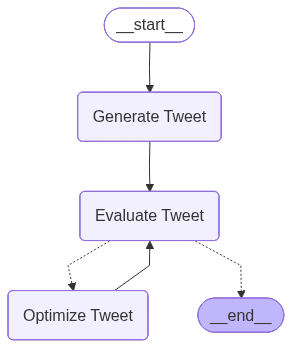

In [9]:
workflow